In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

In [ ]:
#Load Dataset
df = pd.read_csv(r'F:\University projects\calorie_efficiency_dataset.csv')
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (1000000, 15)

First 5 rows:
   age  steps_per_day  active_minutes  calories_burned  sleep_hours  \
0   51           7853              99             1500         6.42   
1   60           4820              78             1500         6.82   
2   59           4251              28             1500         6.99   
3   39           6275              75             1500         6.65   
4   22           6490              82             1500         5.80   

   hydration_liters    bmi  workouts_per_week  muscle_mass_ratio  \
0              3.60  22.34                  3              0.321   
1              4.18  32.30                  6              0.548   
2              2.95  24.71                  2              0.245   
3              2.62  28.80                  1              0.389   
4              0.97  21.92                  2              0.326   

   body_fat_percentage  heart_rate_resting  heart_rate_avg  \
0                0.050                68.5           102.0

In [ ]:
#Separate Features and Target
X = df.drop('calorie_efficiency', axis=1).values
y_raw = df['calorie_efficiency'].values

le = LabelEncoder()
y = le.fit_transform(y_raw)

print("Label Encoding:")
for idx, cls in enumerate(le.classes_):
    print(f"  '{cls}' --> {idx}")

Label Encoding:
  'High Efficiency' --> 0
  'Low Efficiency' --> 1
  'Moderate' --> 2


In [ ]:
#Separate Classes
class_0 = np.array(X[y == 0])
class_1 = np.array(X[y == 1])

print(f"Class 0 ({le.classes_[0]}) samples: {len(class_0)}")
print(f"Class 1 ({le.classes_[1]}) samples: {len(class_1)}")

Class 0 (High Efficiency) samples: 26896
Class 1 (Low Efficiency) samples: 938243


C:\Users\Dell\AppData\Local\Temp\ipykernel_13568\195802640.py:3: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(class_0[:, 0], class_0[:, 6], s=75, facecolors='black',
C:\Users\Dell\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


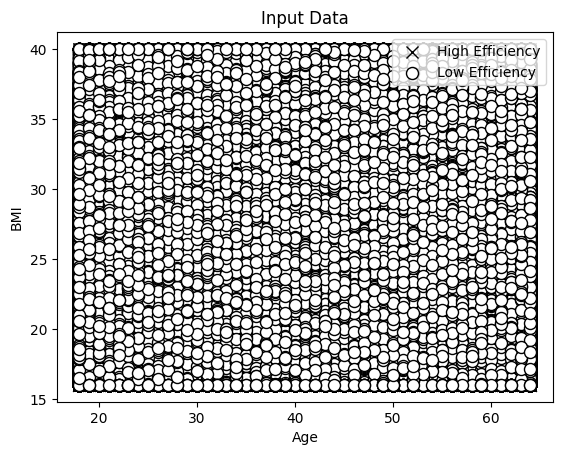

In [ ]:
#Visualize Input Data (Age vs BMI)
plt.figure()
plt.scatter(class_0[:, 0], class_0[:, 6], s=75, facecolors='black',
            edgecolors='black', linewidth=1, marker='x', label=le.classes_[0])
plt.scatter(class_1[:, 0], class_1[:, 6], s=75, facecolors='white',
            edgecolors='black', linewidth=1, marker='o', label=le.classes_[1])
plt.xlabel('Age')
plt.ylabel('BMI')
plt.title('Input Data')
plt.legend()
plt.show()

In [ ]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=5)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Training samples : 750000
Testing  samples : 250000


In [ ]:
#Train Decision Tree Classifier
params = {'random_state': 0, 'max_depth': 4}
classifier = DecisionTreeClassifier(**params)
classifier.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


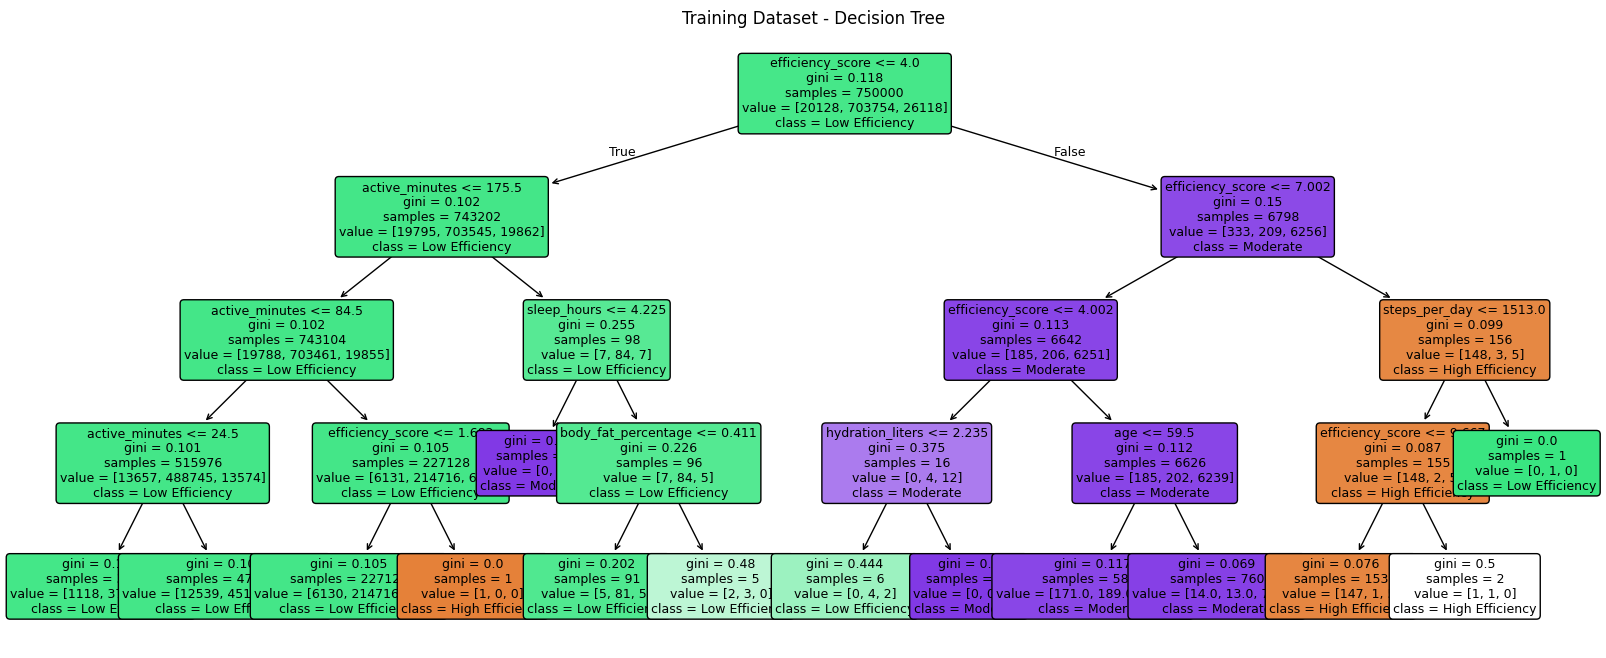

In [ ]:
# Visualize Tree on Training Dataset
feature_names = list(df.drop('calorie_efficiency', axis=1).columns)
class_names = list(le.classes_)

plt.figure(figsize=(20, 8))
plot_tree(classifier, feature_names=feature_names,
          class_names=class_names, filled=True, rounded=True, fontsize=9)
plt.title('Training Dataset - Decision Tree')
plt.show()

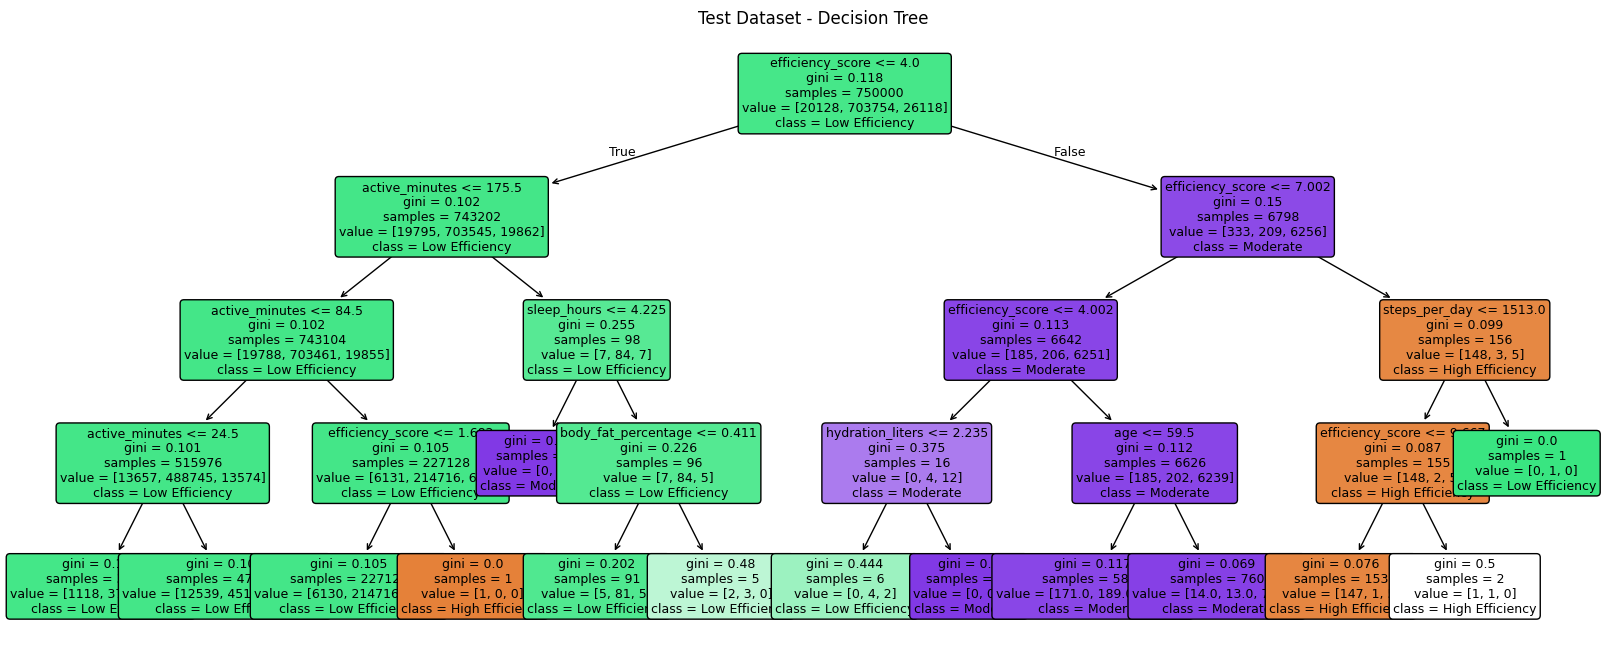

In [ ]:
#Predict on Test Dataset
y_test_pred = classifier.predict(X_test)

plt.figure(figsize=(20, 8))
plot_tree(classifier, feature_names=feature_names,
          class_names=class_names, filled=True, rounded=True, fontsize=9)
plt.title('Test Dataset - Decision Tree')
plt.show()

In [ ]:
#Evaluate Classifier Performance
class_names_report = list(le.classes_)   # automatically picks all classes from your data

print("\n" + "#" * 40)
print("\nClassifier performance on training dataset\n")
print(classification_report(y_train, classifier.predict(X_train),
      target_names=class_names_report))
print("#" * 40 + "\n")

print("#" * 40)
print("\nClassifier performance on test dataset\n")
print(classification_report(y_test, y_test_pred,
      target_names=class_names_report))
print("#" * 40 + "\n")


########################################

Classifier performance on training dataset

                 precision    recall  f1-score   support

High Efficiency       0.96      0.01      0.01     20128
 Low Efficiency       0.95      1.00      0.97    703754
       Moderate       0.94      0.24      0.38     26118

       accuracy                           0.95    750000
      macro avg       0.95      0.42      0.46    750000
   weighted avg       0.95      0.95      0.93    750000

########################################

########################################

Classifier performance on test dataset

                 precision    recall  f1-score   support

High Efficiency       0.89      0.01      0.01      6768
 Low Efficiency       0.95      1.00      0.97    234489
       Moderate       0.95      0.26      0.40      8743

       accuracy                           0.95    250000
      macro avg       0.93      0.42      0.46    250000
   weighted avg       0.95      0.95      0

In [13]:
print("Classes found in your dataset:", le.classes_)
print("Total classes:", len(le.classes_))

Classes found in your dataset: ['High Efficiency' 'Low Efficiency' 'Moderate']
Total classes: 3


In [ ]:
#Compute Training Accuracy
train_accuracy = 100.0 * classifier.score(X_train, y_train)
print("Training accuracy:", round(train_accuracy, 2), "%")

Training accuracy: 94.66 %


In [ ]:
#Compute Test Accuracy  
test_accuracy = 100.0 * classifier.score(X_test, y_test)
print("Test accuracy:", round(test_accuracy, 2), "%")

Test accuracy: 94.68 %


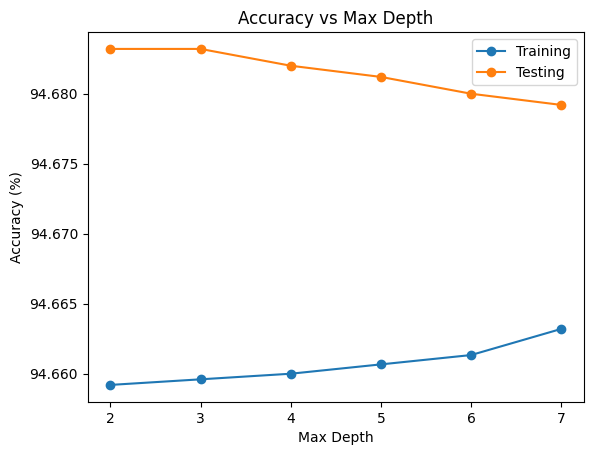

In [ ]:
#Try Different max_depth Values and Compare
max_depth_values = [2, 3, 4, 5, 6, 7]
train_accuracies = []
test_accuracies  = []

for depth in max_depth_values:
    clf = DecisionTreeClassifier(random_state=0, max_depth=depth)
    clf.fit(X_train, y_train)
    train_accuracies.append(100.0 * clf.score(X_train, y_train))
    test_accuracies.append(100.0 * clf.score(X_test, y_test))

plt.figure()
plt.plot(max_depth_values, train_accuracies, 'o-', label='Training')
plt.plot(max_depth_values, test_accuracies,  'o-', label='Testing')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Max Depth')
plt.legend()
plt.show()